# Analysis of Household Energy Consumption in Germany
**Author:** Maximilian Starp  

### Executive Summary
This project analyzes the shifts in energy consumption forms within German households over the last decades. 
The focus lies on the transition from fossil fuels towards renewable energy sources.

### Research Questions
Is the transition from fossil to renewable energy impacting socio-economic fairness? Specifically, is the burden of combating climate change being disproportionately carried by lower-income populations?

In [4]:
# import requirements

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
#from scipy.stats import norm
from scipy.stats import lognorm

## Step 1: Data Acquisition & Loading

In this section, the six core datasets required for the socio-economic impact analysis are imported:

- Household Energy Consumption by Source: Detailed breakdown of energy forms (Electricity, Gas, Renewables, etc.) consumed by German households. The Data has been measured yearly

- Equivalence Income Distribution: Data categorized by income deciles/Quantiles/Quartiles etc. The Data has been measure yearly
    - Definition: The Equivalised Disposable Income is the total income of a household, after tax and other deductions, divided by the number of household members converted into equalised adults (using the OECD scale).

- Electricity Pricing (Historical & Current): Two-part dataset covering price evolution from 1991–2007 and 2007–2025, the data is given for Germany and EU. The Data has been measeured half-yearly.

- Natural Gas Pricing (Heating): Two-part dataset reflecting consumer costs for residential heating from 1985–2007 and 2007–2025, the data is given for Germany and EU. The Data has been measured half-yearly


data sources

In [41]:
# --- Load the Datasets ---

data_files = {
    "energy_mix": "EnergyMix_Households_1990-2024_Germany_annual_KWH.csv",
    "income": "EquivalisedIncome_PerCapita_1995-2025_Germany_EU_annual_EUR.csv",
    "elec_prices_old": "ElectricityPrices_Households_1991-2007_Germany-EU_biannual_KWH.csv",
    "elec_prices_new": "ElectricityPrices_Households_2007-2025_Germany-EU_biannual_KWH.csv",
    "gas_prices_old": "GasPrices_Households_1985-2007_Germany-EU_biannual_GJ.csv",
    "gas_prices_new": "GasPrices_Households_2007-2025_Germany-EU_biannual_KWH.csv",
}

datasets = {}

for key, file in data_files.items():
    try:
        datasets[key] = pd.read_csv(f"./data/{file}")
        print(f"Successfully loaded {key}")
    except FileNotFoundError:
        print(f"Error: {file} not found in directory.")

Successfully loaded energy_mix
Successfully loaded income
Successfully loaded elec_prices_old
Successfully loaded elec_prices_new
Successfully loaded gas_prices_old
Successfully loaded gas_prices_new


# Step 2: Data Harmonization Pipeline - Germany & EU (1995–2024)

This script processes four distinct types of data: **Energy Mix (Consumption of Households)**, **Electricity Prices (for Households)**, **Gas Prices (for Households)**, and **Equivalised Income (per Capita)**. It performs unit normalization, handles methodological changes from the year 2007, and transforms the data from **Long** to **Wide** format for easier analysis.

---

## 1. Global Parameters

* **Timeframe**: The data is strictly filtered for **1995 to 2024**, because in this the biggest Timeframe all Datasets are available

* **Primary Helper (`get_clean_year`)**: Eurostat often uses strings like `"2007-S1"` (Semester 1). This function extracts the first 4 characters and converts them to integers to allow for numerical filtering, also if something is measure biannualy the mean is taken form the both semester to get a annual value.

---

## 2. Energy Mix Processing

**Goal**: Convert household energy consumption into a consistent unit (**kWh**).

* **Unit Conversion**: The raw data is provided in **Terawatt-hours (TWh)**. Since prices are measured in **Kilowatt-hours (kWh)**, the script multiplies all energy values by **1,000,000,000 (10^9)**.

---

## 3. Electricity & Gas Price Harmonization (`process_prices`)

Processing energy prices is complex because Eurostat changed its reporting methodology in **2007**.

### Methodology Stitching (2007 Logic)

* Data **before 2007** is taken from the **Old** dataset.
* Data **from 2007 onwards** is taken from the **New** dataset.
* This prevents overlaps and ensures the most modern data is used for the transition year.

### Gas Unit Normalization

* Old gas data is often in **Gigajoules (GJ)**.
* To match the modern **kWh** standard, the script divides the old values by **277.78**.

### Consumption Band Filtering

To avoid duplicates, the script filters for standard household consumption bands:

* **Electricity**: Band DC (2,500–5,000 kWh/year)
* **Gas**: Band D2 / D3

### Tax Differentiation

* Columns are split to distinguish between:

  * Prices **including all taxes**
  * Prices **excluding taxes**

### Temporal Aggregation

* Price data is **bi-annual** (S1 and S2).
* The script calculates the **annual mean** for each year.

### Dual-Region Filtering
The script identifies and separates data for **Germany** and the **European Union (EU)**.  
This enables direct benchmarking of German energy trends against the European average.

### Column Structure
This logic transforms the vertical Eurostat data into clear, side-by-side columns, for example:

- `Price_Germany_WithTaxes_perKWh`
- `Price_Germany_WithoutTaxes_perKWh`
- `Price_EU_WithTaxes_perKWh`
- `Price_EU_WithoutTaxes_perKWh`

This structure makes it easy to calculate the **tax burden percentage** for any given year.
---

## 4. Income Data Transformation

**Goal**: Convert the vertical Eurostat list into a horizontal table of income deciles.

### Pivot Table

The script transforms the quantile column. Instead of multiple rows per year, it creates a single row with multiple columns:

* `Income_Germany_First_decile`
* `Income_Germany_Second_decile`
* ...
* `Income_EU_First_decile`
* ...

### Metric

* Uses the **Top cut-off point** (or mean where applicable) to represent income levels of different socio-economic groups.

---

## 5. Final Output Structure

The result of this pipeline is four clean DataFrames ready for correlation analysis:

* `df_energy_final`: Annual consumption per carrier in **kWh**
* `df_elec_final`: Annual mean electricity prices in **EUR/kWh**
* `df_gas_final`: Annual mean gas prices in **EUR/kWh**
* `df_income_final`: Annual income thresholds for all deciles in **EUR**

explain: splitting EU, GER


In [9]:
START_YEAR = 1995
END_YEAR = 2024

# --- 1. Helper Functions ---
def get_clean_year(df):
    if 'TIME_PERIOD' in df.columns:
        return df['TIME_PERIOD'].astype(str).str[:4].astype(int)
    return df['Year']

def process_prices(df_old_raw, df_new_raw, is_gas=False):
    df_old = df_old_raw.copy()
    df_new = df_new_raw.copy()
    
    # Standardize Years
    df_old['Year'] = get_clean_year(df_old)
    df_new['Year'] = get_clean_year(df_new)
    
    # IMPORTANT: Filter for the standard household consumption band to avoid duplicates
    # Electricity: Band DC (2500-5000 kWh) | Gas: Band D2 (20-200 GJ)
    if is_gas:
        # Filter for the standard band in both old and new formats
        df_old = df_old[df_old['consom'].str.contains('D3', na=False)] 
        df_new = df_new[df_new['nrg_cons'].str.contains('D2', na=False)]
    else:
        df_old = df_old[df_old['consom'].str.contains('Dc', na=False)]
        df_new = df_new[df_new['nrg_cons'].str.contains('DC', na=False)]

    # 2007 Priority Logic: Remove 2007 from old, keep in new
    df_old = df_old[df_old['Year'] < 2007]
    
    # Reset index before concatenation to avoid "duplicate labels" error
    combined = pd.concat([df_old, df_new], ignore_index=True, sort=False)
    
    # Unit conversion for Gas (GJ -> KWh)
    if is_gas:
        # Apply conversion only to rows where the unit was Gigajoule (the old data)
        mask_old = combined['Year'] < 2007
        combined.loc[mask_old, 'OBS_VALUE'] = combined.loc[mask_old, 'OBS_VALUE'] / 277.78
    
    # Filter timeframe
    combined = combined[(combined['Year'] >= START_YEAR) & (combined['Year'] <= END_YEAR)]
    
    # Create clean Metric names for pivoting
    combined['Country'] = np.where(combined['geo'].str.contains('Germany'), 'Germany', 'EU')
    combined['Tax_Status'] = np.where(combined['tax'].str.contains('Excluding'), 'WithoutTaxes', 'WithTaxes')
    
    # Group by Year, Country, Tax_Status and average the semesters (S1, S2)
    final = combined.groupby(['Year', 'Country', 'Tax_Status'])['OBS_VALUE'].mean().unstack(level=[1, 2])
    
    # Flatten column names: e.g., "Price_Germany_WithTaxes_perKWh"
    prefix = "Gas" if is_gas else "Elec"
    final.columns = [f"{prefix}_{country}_{tax}_perKWh" for country, tax in final.columns]
    
    return final.reset_index()

# --- 2. Run Processing ---

# Energy Mix
df_mix = datasets["energy_mix"].copy()
df_mix['Year'] = get_clean_year(df_mix)
energy_cols = ['Mineral Oils', 'Gases', 'Electricity', 'District Heating', 
               'Coal', 'Renewable Energies', 'Other Energy Sources', 'All Energy Sources']
for col in energy_cols:
    if col in df_mix.columns:
        df_mix[col] = df_mix[col].astype(float) * 1_000_000_000 # TWh to KWh
df_energy_final = df_mix[(df_mix['Year'] >= START_YEAR) & (df_mix['Year'] <= END_YEAR)].reset_index(drop=True)

# Prices
df_elec_final = process_prices(datasets["elec_prices_old"], datasets["elec_prices_new"], is_gas=False)
df_gas_final = process_prices(datasets["gas_prices_old"], datasets["gas_prices_new"], is_gas=True)

# Income
df_inc = datasets["income"].copy()
df_inc['Year'] = get_clean_year(df_inc)
df_inc = df_inc[(df_inc['Year'] >= START_YEAR) & (df_inc['Year'] <= END_YEAR)]

# Clean income geography names
df_inc['geo_short'] = np.where(df_inc['geo'] == 'Germany', 'Germany', 'EU')

# Pivot Deciles
df_income_final = df_inc.pivot_table(
    index='Year', 
    columns=['geo_short', 'quantile'], 
    values='OBS_VALUE',
    aggfunc='mean' # In case of duplicate reporting
)
df_income_final.columns = [f"Income_{geo}_{q.replace(' ', '_')}" for geo, q in df_income_final.columns]
df_income_final = df_income_final.reset_index()

# --- 3. Split into Europe and Germany Dataframes ---
def split_by_region(df, region_name):
    """
    Keeps 'Year' and any column containing the specific region name.
    """
    cols_to_keep = ['Year'] + [col for col in df.columns if region_name in col]
    return df[cols_to_keep].copy()

# Split Electricity Prices
df_elec_GER = split_by_region(df_elec_final, "Germany")
df_elec_EU  = split_by_region(df_elec_final, "EU")

# Split Gas Prices
df_gas_GER = split_by_region(df_gas_final, "Germany")
df_gas_EU  = split_by_region(df_gas_final, "EU")

# Split Income Data
df_income_GER = split_by_region(df_income_final, "Germany")
df_income_EU  = split_by_region(df_income_final, "EU")

Explanaiton: missing

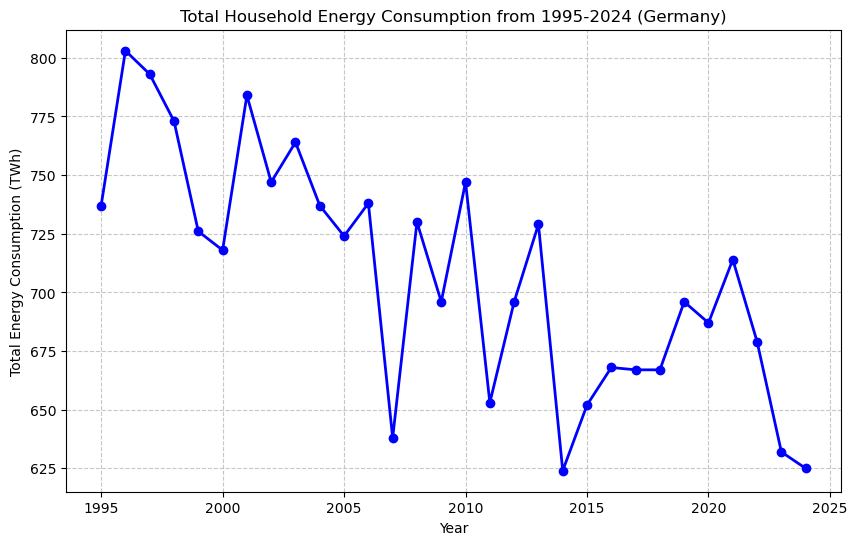

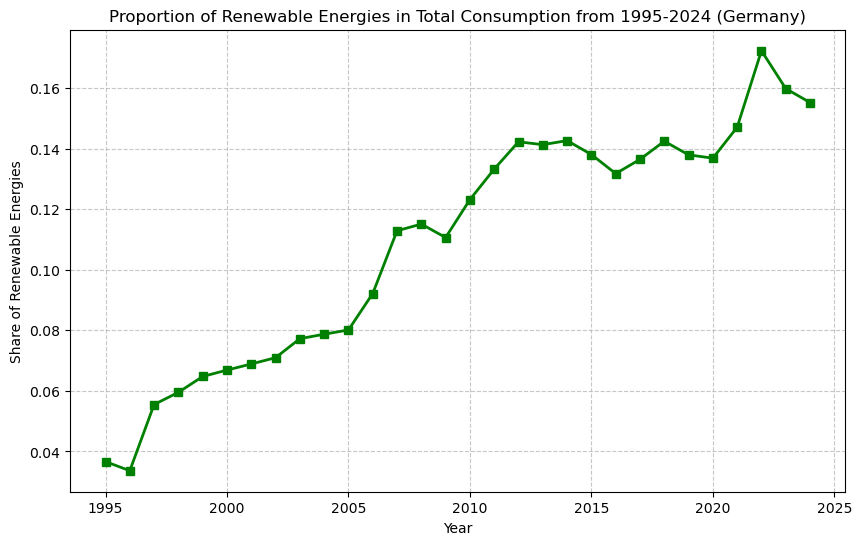

In [10]:
# 2. Calculation for Renewable Share
df_energy_final['Renewable_Share'] = df_energy_final['Renewable Energies'] / df_energy_final['All Energy Sources']

# --- FIGURE 1: Total Energy Consumption ---
plt.figure(figsize=(10, 6))
plt.plot(
    df_energy_final['Year'], 
    df_energy_final['All Energy Sources'] / 1_000_000_000, # Display in TWh
    marker='o', 
    color='blue', 
    linewidth=2
)
plt.xlabel("Year")
plt.ylabel("Total Energy Consumption (TWh)")
plt.title("Total Household Energy Consumption from 1995-2024 (Germany)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('Graphs_output/total_energy_consumption.png', dpi=300)
#plt.close()

# --- FIGURE 2: Share of Renewable Energies ---
plt.figure(figsize=(10, 6))
plt.plot(
    df_energy_final['Year'], 
    df_energy_final['Renewable_Share'], 
    marker='s', 
    color='green', 
    linewidth=2
)
plt.xlabel("Year")
plt.ylabel("Share of Renewable Energies")
plt.title("Proportion of Renewable Energies in Total Consumption from 1995-2024 (Germany)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('Graphs_output/renewable_share.png', dpi=300)
#plt.close()

Analysis: missing

desrciption

In [38]:
def lognorm_cdf(x, sigma, scale):
    """The standard Log-Normal CDF function."""
    return lognorm.cdf(x, sigma, scale=scale)

PROB_MAP = {
    'First_percentile': 0.01, 'Second_percentile': 0.02, 'Third_percentile': 0.03, 'Fourth_percentile': 0.04,
    'Fifth_percentile': 0.05, 'Ninety-fifth_percentile': 0.95, 'Ninety-sixth_percentile': 0.96,
    'Ninety-seventh_percentile': 0.97, 'Ninety-eighth_percentile': 0.98, 'Ninety-ninth_percentile': 0.99,
    'First_decile': 0.1, 'Second_decile': 0.2, 'Third_decile': 0.3, 'Fourth_decile': 0.4,
    'Fifth_decile': 0.5, 'Sixth_decile': 0.6, 'Seventh_decile': 0.7, 'Eighth_decile': 0.8, 'Ninth_decile': 0.9,
    'First_quartile': 0.25, 'Second_quartile': 0.5, 'Third_quartile': 0.75,
    'First_quintile': 0.2, 'Second_quintile': 0.4, 'Third_quintile': 0.6, 'Fourth_quintile': 0.8
}

def fit_regional_income(df_input, region_name):
    final_results = []
    
    # Prefix to match columns: e.g., "Income_Germany_" or "Income_EU_"
    prefix = f"Income_{region_name}_"
    income_cols = [c for c in df_input.columns if prefix in c]
    
    for _, row in df_input.iterrows():
        year = row['Year']
        x_vals = []
        y_vals = []
        
        # 1. Filter out NaNs and match column probabilities
        for col in income_cols:
            suffix = col.replace(prefix, "")
            if suffix in PROB_MAP and pd.notnull(row[col]):
                # Ensure the value is a float and above zero (log-normal requirement)
                val = float(row[col])
                if val > 0:
                    x_vals.append(val)
                    y_vals.append(PROB_MAP[suffix])
        
        # 2. Skip the year if we don't have enough data points (need at least 2)
        if len(x_vals) < 3:
            continue 

        # 3. Convert to arrays and Sort
        x_vals = np.array(x_vals)
        y_vals = np.array(y_vals)
        idx = np.argsort(x_vals)
        x_vals, y_vals = x_vals[idx], y_vals[idx]
        
        # 4. Initial Guess (p0)
        # We look for the income value closest to the 50% probability (median)
        median_guess = x_vals[np.argmin(np.abs(y_vals - 0.5))]
        p0 = [0.5, median_guess] 
        
        # 5. Fit the Curve
        # We use a large max_nfev (function evaluations) to help convergence
        popt, _ = curve_fit(lognorm_cdf, x_vals, y_vals, p0=p0, maxfev=2000)
        
        sigma_fit = popt[0]
        mu_fit = np.log(popt[1]) # mu is ln(scale)
        
        # 6. Calculate Fitting Error (MSE)
        error = np.mean((y_vals - lognorm_cdf(x_vals, *popt))**2)
        
        final_results.append({
            'Year': int(year),
            'mu': mu_fit,
            'sigma': sigma_fit,
            'fitting_error': error
        })
        
    return pd.DataFrame(final_results)

# Execute
df_params_GER = fit_regional_income(df_income_GER, "Germany")
df_params_EU = fit_regional_income(df_income_EU, "EU")

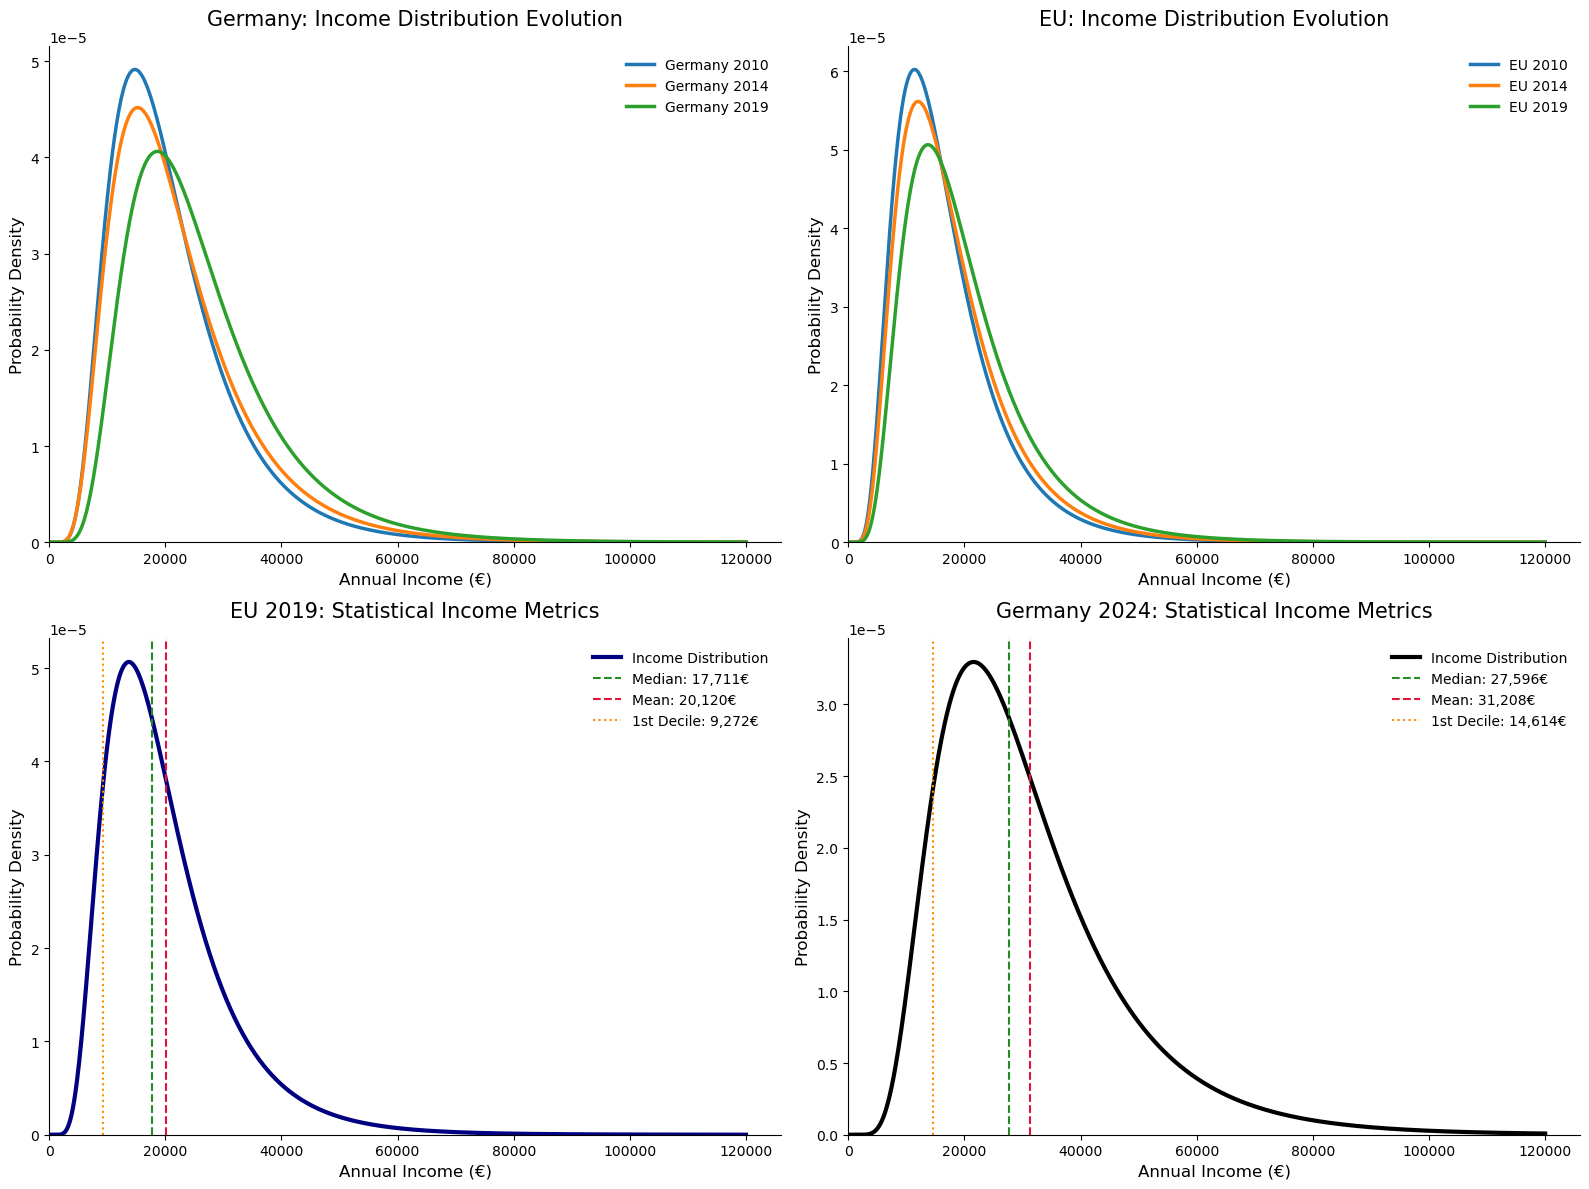

In [37]:
def get_pdf_data(df_params, year, x_range):
    # Retrieve mu and sigma for the specific year
    row = df_params[df_params['Year'] == year].iloc[0]
    mu, sigma = row['mu'], row['sigma']
    
    # Calculate PDF
    pdf = lognorm.pdf(x_range, sigma, scale=np.exp(mu))
    
    # Calculate specific metrics
    median = np.exp(mu)
    mean = np.exp(mu + (sigma**2 / 2))
    first_decile = lognorm.ppf(0.10, sigma, scale=np.exp(mu))
    
    return pdf, median, mean, first_decile

# Range for income axis (starting slightly above 0 to avoid log errors)
x_axis = np.linspace(0.1, 120000, 1000)
years_to_compare = [2010, 2014, 2019]

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# --- PLOT 1: Germany 3-Year Comparison ---
for y in years_to_compare:
    pdf, _, _, _ = get_pdf_data(df_params_GER, y, x_axis)
    axs[0, 0].plot(x_axis, pdf, label=f'Germany {y}', lw=2.5)
axs[0, 0].set_title("Germany: Income Distribution Evolution", fontsize=15, pad=15)

# --- PLOT 2: EU 3-Year Comparison ---
for y in years_to_compare:
    if y in df_params_EU['Year'].values:
        pdf, _, _, _ = get_pdf_data(df_params_EU, y, x_axis)
        axs[0, 1].plot(x_axis, pdf, label=f'EU {y}', lw=2.5)
axs[0, 1].set_title("EU: Income Distribution Evolution", fontsize=15, pad=15)

# --- PLOT 3: EU 2019 Key Metrics ---
pdf_eu, med_eu, avg_eu, dec_eu = get_pdf_data(df_params_EU, 2019, x_axis)
axs[1, 0].plot(x_axis, pdf_eu, color='navy', lw=3, label='Income Distribution')
axs[1, 0].axvline(med_eu, color='forestgreen', ls='--', label=f'Median: {med_eu:,.0f}€')
axs[1, 0].axvline(avg_eu, color='crimson', ls='--', label=f'Mean: {avg_eu:,.0f}€')
axs[1, 0].axvline(dec_eu, color='darkorange', ls=':', label=f'1st Decile: {dec_eu:,.0f}€')
axs[1, 0].set_title("EU 2019: Statistical Income Metrics", fontsize=15, pad=15)

# --- PLOT 4: Germany 2024 Key Metrics ---
# (Using 2024 as requested; ensure your df_params_GER has this year)
pdf_ger, med_ger, avg_ger, dec_ger = get_pdf_data(df_params_GER, 2024, x_axis)
axs[1, 1].plot(x_axis, pdf_ger, color='black', lw=3, label='Income Distribution')
axs[1, 1].axvline(med_ger, color='forestgreen', ls='--', label=f'Median: {med_ger:,.0f}€')
axs[1, 1].axvline(avg_ger, color='crimson', ls='--', label=f'Mean: {avg_ger:,.0f}€')
axs[1, 1].axvline(dec_ger, color='darkorange', ls=':', label=f'1st Decile: {dec_ger:,.0f}€')
axs[1, 1].set_title("Germany 2024: Statistical Income Metrics", fontsize=15, pad=15)

# --- Global Formatting for all 4 Plots ---
for ax in axs.flat:
    ax.set_xlabel("Annual Income (€)", fontsize=12)
    ax.set_ylabel("Probability Density", fontsize=12)
    ax.legend(frameon=False, loc='upper right')
    
    # 1. Ensure 0,0 is the corner
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    
    # 2. No grid
    ax.grid(False)
    
    # Clean up spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Analysis

Describe

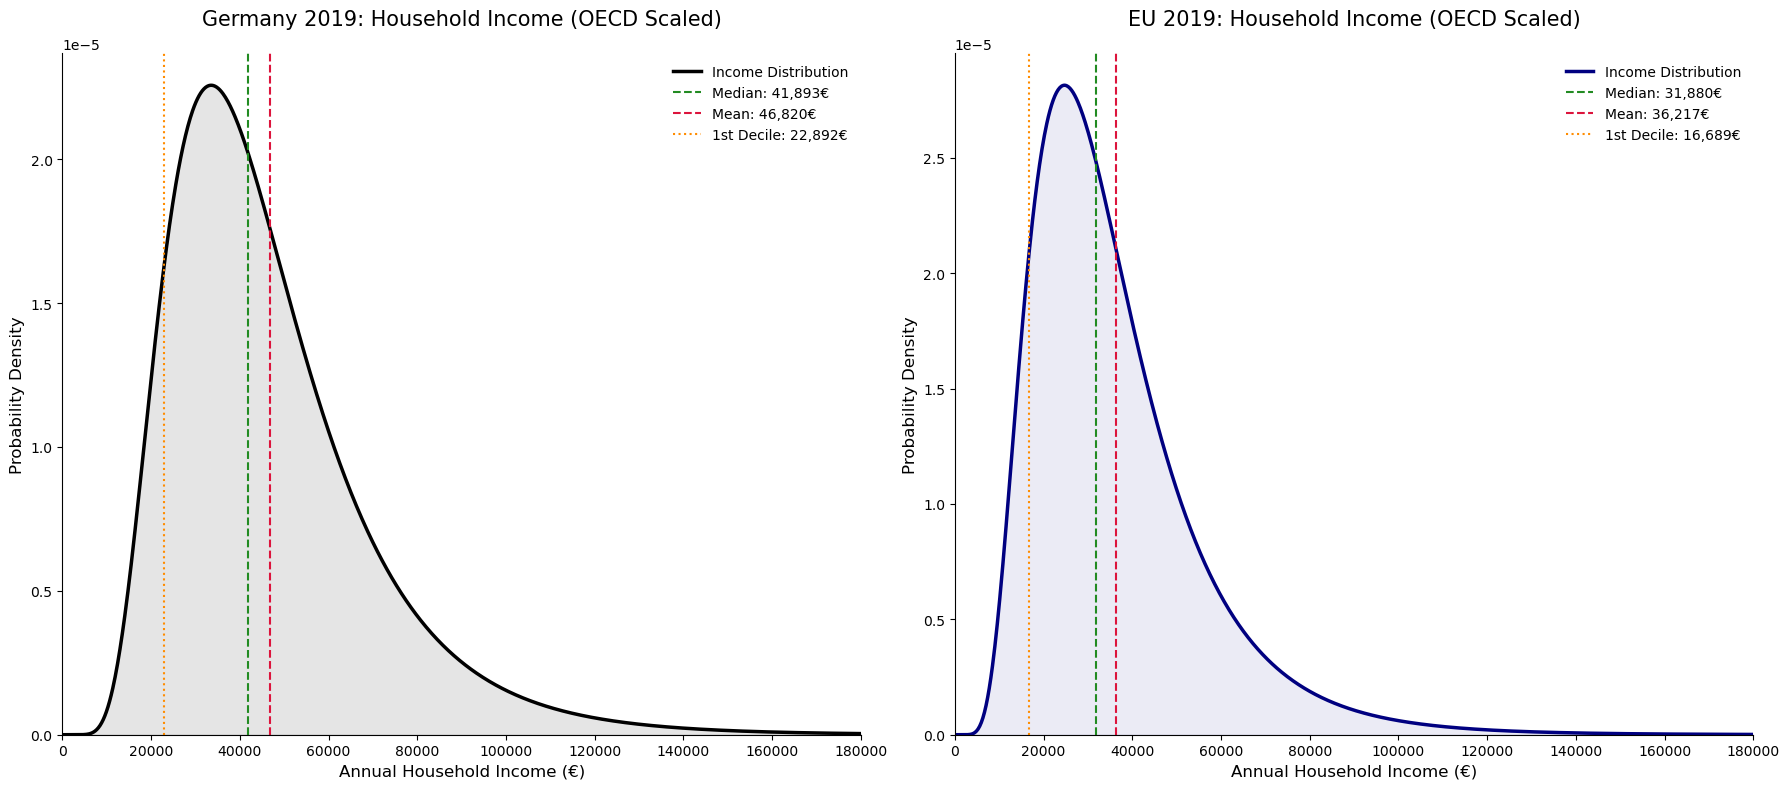

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# --- 1. OECD Scale Configuration ---
# 1st Adult: 1.0, 2nd Adult: 0.5, 1 Child: 0.3
EQUIVALENCE_FACTOR = 1.8 

def get_hh_params(df_individual):
    df_hh = df_individual.copy()
    # Shift mu by the log of the equivalence factor
    df_hh['mu'] = df_individual['mu'] + np.log(EQUIVALENCE_FACTOR)
    df_hh['sigma'] = df_individual['sigma']
    return df_hh

# Transform dataframes
df_params_GER_hh = get_hh_params(df_params_GER)
df_params_EU_hh = get_hh_params(df_params_EU)

# --- 2. Plotting Logic ---
def get_pdf_data(df_params, year, x_range):
    row = df_params[df_params['Year'] == year].iloc[0]
    mu, sigma = row['mu'], row['sigma']
    pdf = lognorm.pdf(x_range, sigma, scale=np.exp(mu))
    
    median = np.exp(mu)
    mean = np.exp(mu + (sigma**2 / 2))
    first_decile = lognorm.ppf(0.10, sigma, scale=np.exp(mu))
    
    return pdf, median, mean, first_decile

# Requested range: 0 to 180,000
x_axis = np.linspace(0.1, 180000, 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# --- Plot 1: Germany 2019 (Household) ---
pdf_g, med_g, avg_g, dec_g = get_pdf_data(df_params_GER_hh, 2019, x_axis)
ax1.plot(x_axis, pdf_g, color='black', lw=2.5, label='Income Distribution')
ax1.fill_between(x_axis, pdf_g, color='black', alpha=0.1) # Light fill
ax1.axvline(med_g, color='forestgreen', ls='--', label=f'Median: {med_g:,.0f}€')
ax1.axvline(avg_g, color='crimson', ls='--', label=f'Mean: {avg_g:,.0f}€')
ax1.axvline(dec_g, color='darkorange', ls=':', label=f'1st Decile: {dec_g:,.0f}€')
ax1.set_title("Germany 2019: Household Income (OECD Scaled)", fontsize=15, pad=20)

# --- Plot 2: EU 2019 (Household) ---
pdf_e, med_e, avg_e, dec_e = get_pdf_data(df_params_EU_hh, 2019, x_axis)
ax2.plot(x_axis, pdf_e, color='navy', lw=2.5, label='Income Distribution')
ax2.fill_between(x_axis, pdf_e, color='navy', alpha=0.08) # Light fill
ax2.axvline(med_e, color='forestgreen', ls='--', label=f'Median: {med_e:,.0f}€')
ax2.axvline(avg_e, color='crimson', ls='--', label=f'Mean: {avg_e:,.0f}€')
ax2.axvline(dec_e, color='darkorange', ls=':', label=f'1st Decile: {dec_e:,.0f}€')
ax2.set_title("EU 2019: Household Income (OECD Scaled)", fontsize=15, pad=20)

# --- Formatting for both plots ---
for ax in [ax1, ax2]:
    ax.set_xlabel("Annual Household Income (€)", fontsize=12)
    ax.set_ylabel("Probability Density", fontsize=12)
    ax.set_xlim(0, 180000)
    ax.set_ylim(bottom=0)
    ax.grid(False)
    ax.legend(frameon=False, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

short analysis

describe
explain assumptions

In [43]:
# --- 1. Constants & Assumptions (Stay the same) ---
HH_SIZE = 3
SQUARE_METERS = 70
GAS_KWH_PER_QM = 120
ANNUAL_GAS_CONSUMPTION = SQUARE_METERS * GAS_KWH_PER_QM  # 8,400 kWh
ANNUAL_ELEC_CONSUMPTION = 4000  # 4,000 kWh

def calculate_regional_costs(df_elec, df_gas, region_name):
    """
    Merges regional price data and calculates total annual costs based on consumption.
    """
    # Merge Elec and Gas prices on Year
    df_merged = pd.merge(df_elec, df_gas, on='Year', how='inner')
    
    # Identify price columns dynamically
    # Expecting names like: Elec_Germany_WithTaxes_perKWh
    col_elec_tax = f"Elec_{region_name}_WithTaxes_perKWh"
    col_elec_no_tax = f"Elec_{region_name}_WithoutTaxes_perKWh"
    col_gas_tax = f"Gas_{region_name}_WithTaxes_perKWh"
    col_gas_no_tax = f"Gas_{region_name}_WithoutTaxes_perKWh"
    
    # Initialize Cost DataFrame
    df_costs = pd.DataFrame({'Year': df_merged['Year']})
    
    # Calculate Electricity Costs
    df_costs['Electricity_Cost_WithTaxes'] = df_merged[col_elec_tax] * ANNUAL_ELEC_CONSUMPTION
    df_costs['Electricity_Cost_WithoutTaxes'] = df_merged[col_elec_no_tax] * ANNUAL_ELEC_CONSUMPTION
    
    # Calculate Gas Costs
    df_costs['Gas_Cost_WithTaxes'] = df_merged[col_gas_tax] * ANNUAL_GAS_CONSUMPTION
    df_costs['Gas_Cost_WithoutTaxes'] = df_merged[col_gas_no_tax] * ANNUAL_GAS_CONSUMPTION
    
    # Calculate Total Energy Costs
    df_costs['Total_Energy_Cost_WithTaxes'] = (df_costs['Electricity_Cost_WithTaxes'] + 
                                               df_costs['Gas_Cost_WithTaxes'])
    
    df_costs['Total_Energy_Cost_WithoutTaxes'] = (df_costs['Electricity_Cost_WithoutTaxes'] + 
                                                  df_costs['Gas_Cost_WithoutTaxes'])
    
    # Return rounded and clean result
    return df_costs.round(2).dropna().reset_index(drop=True)

# --- 2. Execute for both Regions ---

df_costs_GER = calculate_regional_costs(df_elec_GER, df_gas_GER, "Germany")
df_costs_EU  = calculate_regional_costs(df_elec_EU, df_gas_EU, "EU")

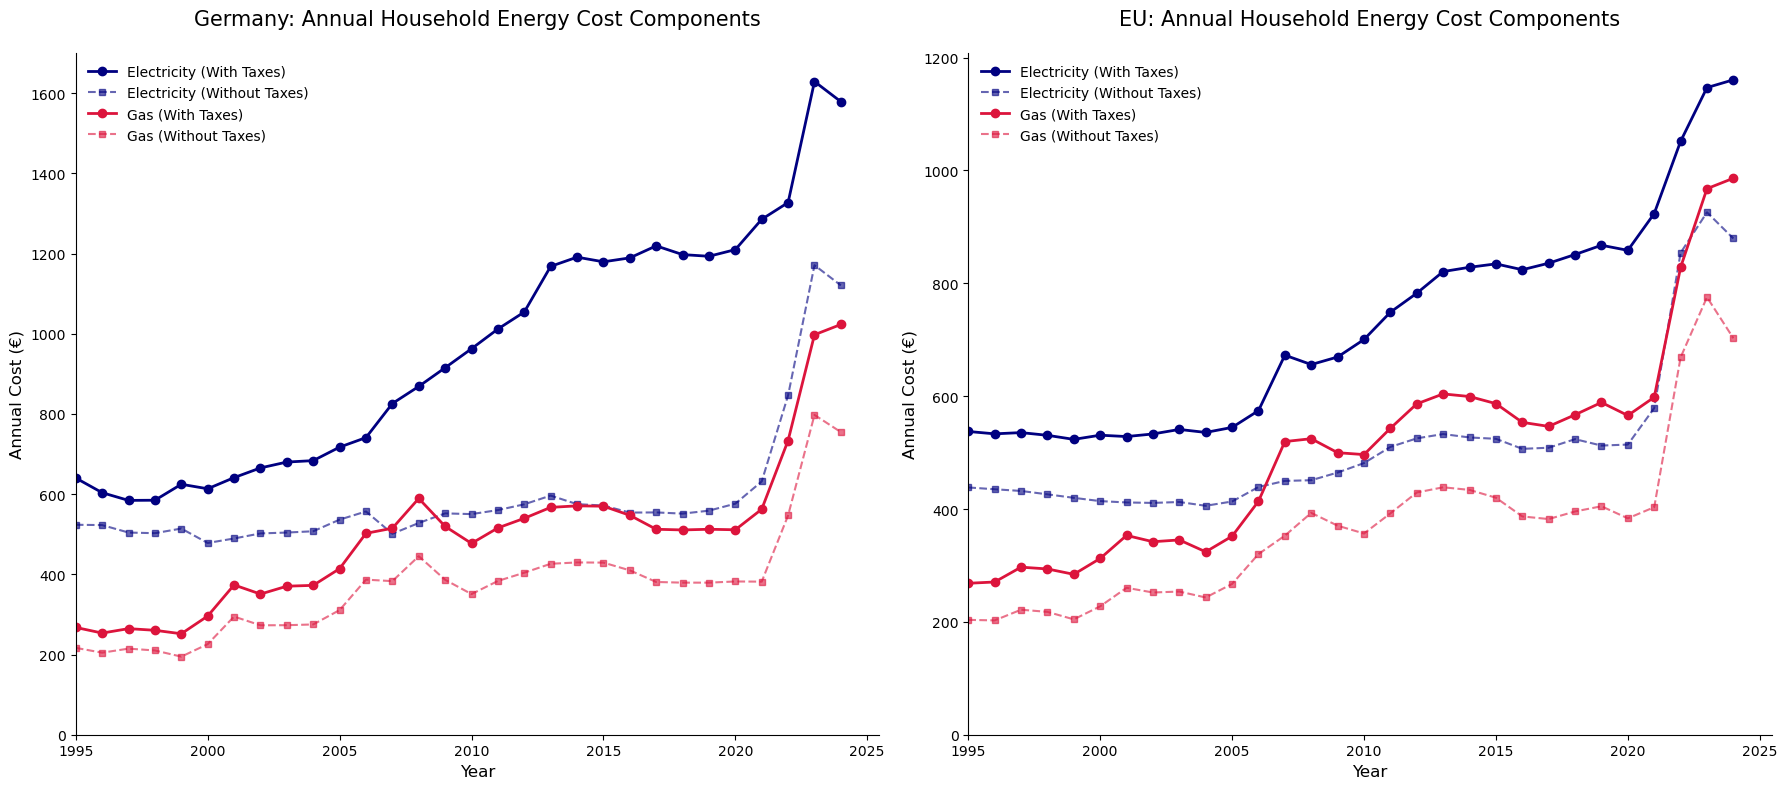

In [45]:
import matplotlib.pyplot as plt

def plot_regional_energy_breakdown(df_costs, region_name, ax):
    """
    Plots annual electricity and gas costs with specific markers, 
    excluding total costs, with origin at the bottom-left corner.
    """
    # 1. Plot Electricity Costs (With and Without Taxes)
    ax.plot(df_costs['Year'], df_costs['Electricity_Cost_WithTaxes'], 
            marker='o', markersize=6, color='navy', lw=2, 
            label='Electricity (With Taxes)')
    
    ax.plot(df_costs['Year'], df_costs['Electricity_Cost_WithoutTaxes'], 
            marker='s', markersize=5, color='navy', lw=1.5, ls='--', alpha=0.6, 
            label='Electricity (Without Taxes)')
    
    # 2. Plot Gas Costs (With and Without Taxes)
    ax.plot(df_costs['Year'], df_costs['Gas_Cost_WithTaxes'], 
            marker='o', markersize=6, color='crimson', lw=2, 
            label='Gas (With Taxes)')
    
    ax.plot(df_costs['Year'], df_costs['Gas_Cost_WithoutTaxes'], 
            marker='s', markersize=5, color='crimson', lw=1.5, ls='--', alpha=0.6, 
            label='Gas (Without Taxes)')

    # --- Formatting ---
    ax.set_title(f"{region_name}: Annual Household Energy Cost Components", fontsize=15, pad=20)
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("Annual Cost (€)", fontsize=12)
    
    # Ensure 0:0 is the bottom left corner
    # (Y-axis starts at 0, X-axis starts at the first year of data)
    ax.set_ylim(bottom=0)
    ax.set_xlim(left=df_costs['Year'].min())
    
    # Remove grid
    ax.grid(False)
    
    # Clean up visual style (remove top and right spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Legend in English with values
    ax.legend(frameon=False, loc='upper left', fontsize=10)

# Create a figure with two subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Plot for Germany
plot_regional_energy_breakdown(df_costs_GER, "Germany", ax1)

# Plot for EU
plot_regional_energy_breakdown(df_costs_EU, "EU", ax2)

plt.tight_layout()
plt.show()

Analye

describe

In [47]:
def calculate_energy_poverty_df(df_costs, df_params_hh):
    """
    Calculates the critical income threshold and the percentage of 
    households in energy poverty using the Log-Normal CDF.
    """
    # Merge the energy costs and household income parameters by Year
    df_merged = pd.merge(df_costs, df_params_hh, on='Year', how='inner')
    
    # 1. Define Critical Income (Threshold where energy cost is exactly 10% of income)
    # Calculation: Income = Cost / 0.10  => Income = Cost * 10
    df_merged['Critical_Income_WithTaxes'] = df_merged['Total_Energy_Cost_WithTaxes'] * 10
    df_merged['Critical_Income_WithoutTaxes'] = df_merged['Total_Energy_Cost_WithoutTaxes'] * 10
    
    # 2. Calculate Percentage of households below the Critical Income
    # We use the CDF of the log-normal distribution: lognorm.cdf(x, sigma, scale=exp(mu))
    df_merged['Percentage_EnergyPoverty_WithTaxes'] = df_merged.apply(
        lambda r: lognorm.cdf(r['Critical_Income_WithTaxes'], r['sigma'], scale=np.exp(r['mu'])) * 100, axis=1
    )
    
    df_merged['Percentage_EnergyPoverty_WithoutTaxes'] = df_merged.apply(
        lambda r: lognorm.cdf(r['Critical_Income_WithoutTaxes'], r['sigma'], scale=np.exp(r['mu'])) * 100, axis=1
    )
    
    # Select only the relevant columns for the final dataframe
    final_cols = [
        'Year', 
        'Critical_Income_WithTaxes', 
        'Critical_Income_WithoutTaxes', 
        'Percentage_EnergyPoverty_WithTaxes', 
        'Percentage_EnergyPoverty_WithoutTaxes'
    ]
    
    return df_merged[final_cols].round(2)

# --- Generate the Energy Poverty Dataframes ---
energy_pov_ger = calculate_energy_poverty_df(df_costs_GER, df_params_GER_hh)
energy_pov_eu = calculate_energy_poverty_df(df_costs_EU, df_params_EU_hh)

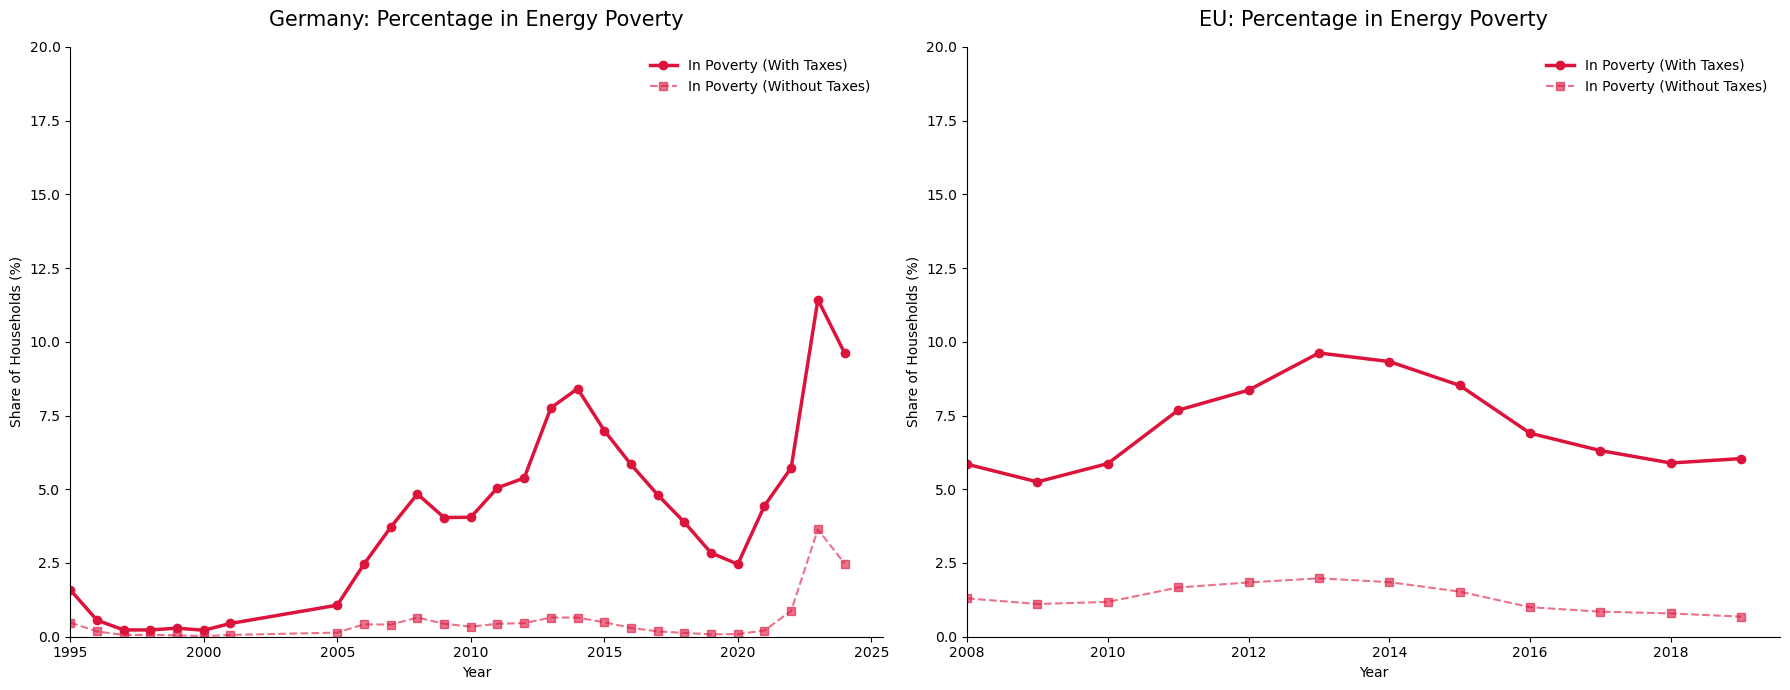

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

def plot_poverty_trend(df, region_name, ax):
    ax.plot(df['Year'], df['Percentage_EnergyPoverty_WithTaxes'], 
            marker='o', color='crimson', lw=2.5, label='In Poverty (With Taxes)')
    ax.plot(df['Year'], df['Percentage_EnergyPoverty_WithoutTaxes'], 
            marker='s', color='crimson', lw=1.5, ls='--', alpha=0.6, label='In Poverty (Without Taxes)')
    
    ax.set_title(f"{region_name}: Percentage in Energy Poverty", fontsize=15, pad=15)
    ax.set_xlabel("Year")
    ax.set_ylabel("Share of Households (%)")
    ax.set_ylim(0, max(df['Percentage_EnergyPoverty_WithTaxes'].max() + 5, 20))
    ax.set_xlim(left=df['Year'].min())
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False)

plot_poverty_trend(energy_pov_ger, "Germany", ax1)
plot_poverty_trend(energy_pov_eu, "EU", ax2)

plt.tight_layout()
plt.show()

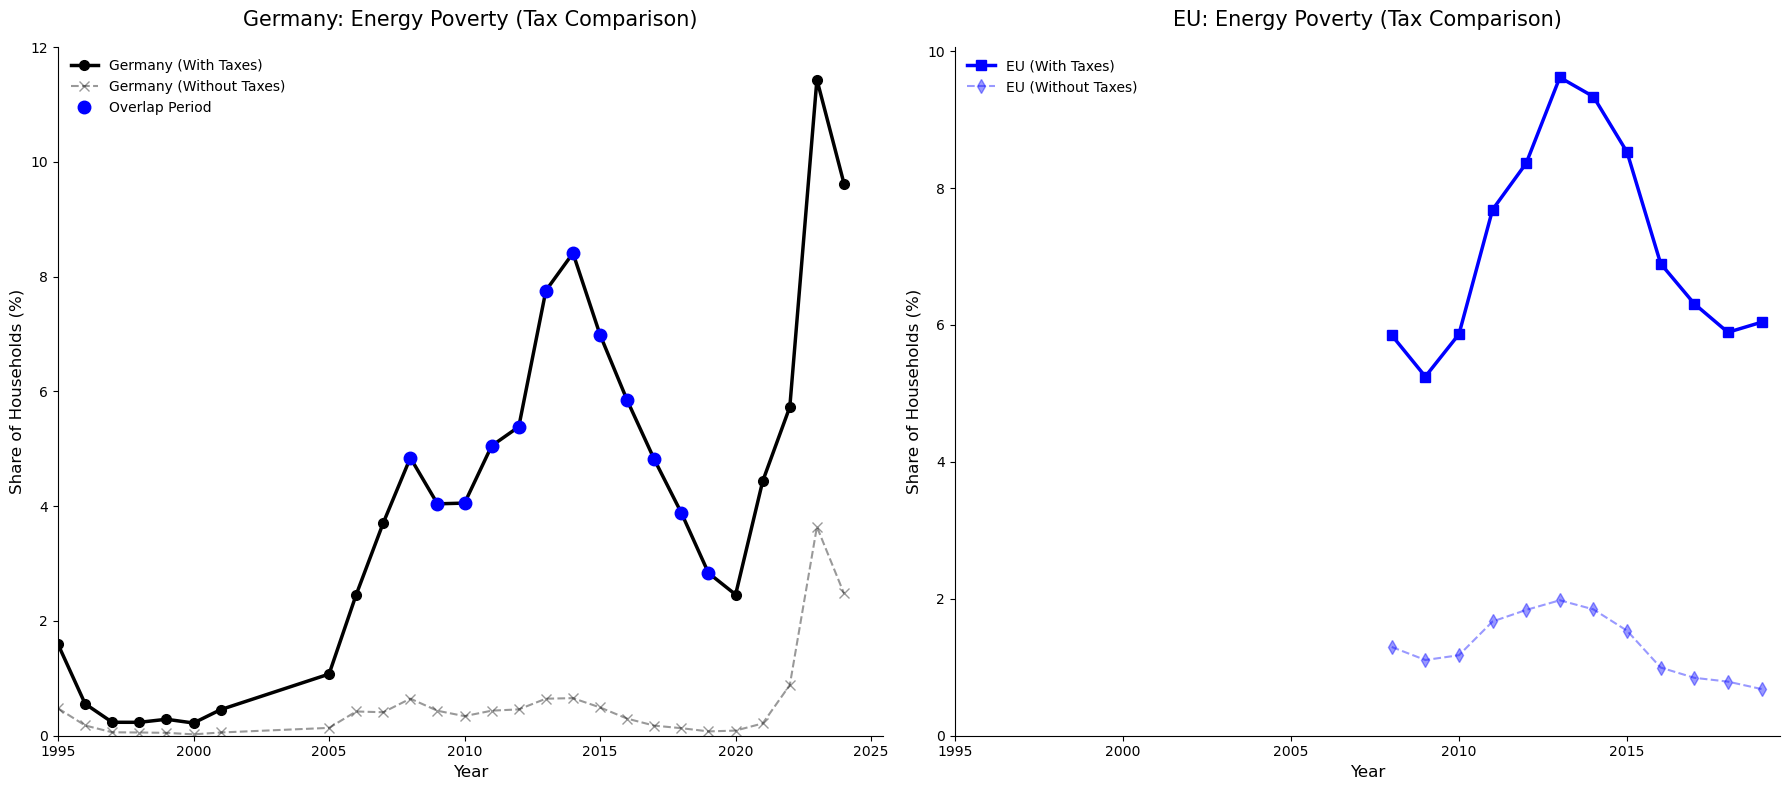

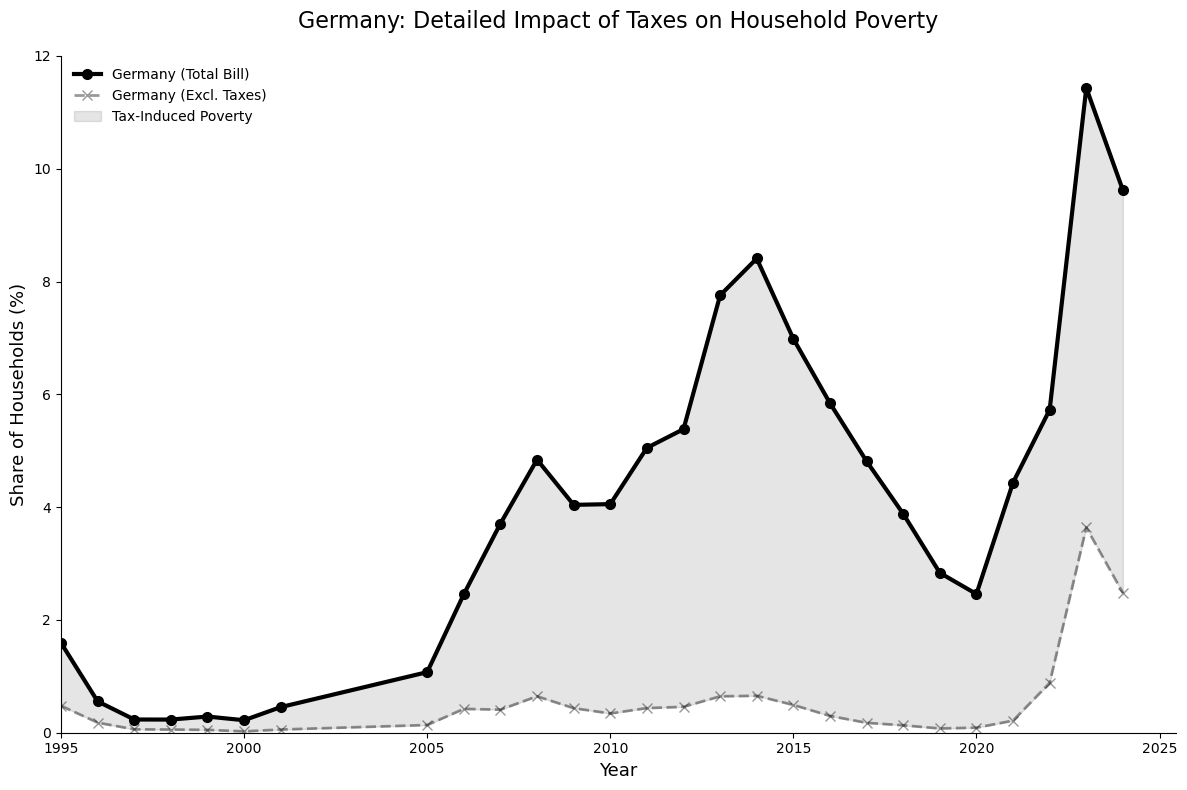

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Formatting Constants ---
GER_COLOR = 'black'
EU_COLOR = 'blue'
ALPHA_NO_TAX = 0.4
MARKER_SIZE = 7

# --- PLOT 1: Comparative Development (Germany vs EU) ---
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Left Subplot: Germany
# Full line With Taxes
ax1.plot(energy_pov_ger['Year'], energy_pov_ger['Pov_Tax'], 
         color=GER_COLOR, lw=2.5, marker='o', ms=MARKER_SIZE, label='Germany (With Taxes)')
# Full line Without Taxes (Alpha)
ax1.plot(energy_pov_ger['Year'], energy_pov_ger['Pov_NoTax'], 
         color=GER_COLOR, lw=1.5, ls='--', marker='x', ms=MARKER_SIZE, alpha=ALPHA_NO_TAX, label='Germany (Without Taxes)')

# Overlap Highlight: Blue marker/line where EU and GER intersect
overlap_data = energy_pov_ger[energy_pov_ger['Year'].isin(overlap_years)]
ax1.plot(overlap_data['Year'], overlap_data['Pov_Tax'], 
         color=EU_COLOR, lw=0, marker='o', ms=MARKER_SIZE + 2, label='Overlap Period')

ax1.set_title("Germany: Energy Poverty (Tax Comparison)", fontsize=15, pad=15)

# Right Subplot: EU Development
ax2.plot(energy_pov_eu['Year'], energy_pov_eu['Pov_Tax'], 
         color=EU_COLOR, lw=2.5, marker='s', ms=MARKER_SIZE, label='EU (With Taxes)')
ax2.plot(energy_pov_eu['Year'], energy_pov_eu['Pov_NoTax'], 
         color=EU_COLOR, lw=1.5, ls='--', marker='d', ms=MARKER_SIZE, alpha=ALPHA_NO_TAX, label='EU (Without Taxes)')

ax2.set_title("EU: Energy Poverty (Tax Comparison)", fontsize=15, pad=15)

# Formatting for Comparison Plot
for ax in [ax1, ax2]:
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("Share of Households (%)", fontsize=12)
    ax.set_ylim(bottom=0)
    ax.set_xlim(left=min(energy_pov_ger['Year'].min(), energy_pov_eu['Year'].min()))
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc='upper left')

plt.tight_layout()
plt.show()

# --- PLOT 2: Germany Only (Detailed Tax Impact) ---
plt.figure(figsize=(12, 8))
ax_ger = plt.gca()

ax_ger.plot(energy_pov_ger['Year'], energy_pov_ger['Pov_Tax'], 
            color=GER_COLOR, lw=3, marker='o', ms=MARKER_SIZE, label='Germany (Total Bill)')
ax_ger.plot(energy_pov_ger['Year'], energy_pov_ger['Pov_NoTax'], 
            color=GER_COLOR, lw=2, ls='--', marker='x', ms=MARKER_SIZE, alpha=ALPHA_NO_TAX, label='Germany (Excl. Taxes)')

# Fill the area to emphasize the government's share in poverty rates
ax_ger.fill_between(energy_pov_ger['Year'], 
                    energy_pov_ger['Pov_NoTax'], 
                    energy_pov_ger['Pov_Tax'], 
                    color=GER_COLOR, alpha=0.1, label='Tax-Induced Poverty')

ax_ger.set_title("Germany: Detailed Impact of Taxes on Household Poverty", fontsize=16, pad=20)
ax_ger.set_xlabel("Year", fontsize=13)
ax_ger.set_ylabel("Share of Households (%)", fontsize=13)
ax_ger.set_xlim(left=energy_pov_ger['Year'].min())
ax_ger.set_ylim(bottom=0)
ax_ger.grid(False)
ax_ger.spines['top'].set_visible(False)
ax_ger.spines['right'].set_visible(False)
ax_ger.legend(frameon=False, loc='upper left')

plt.tight_layout()
plt.show()

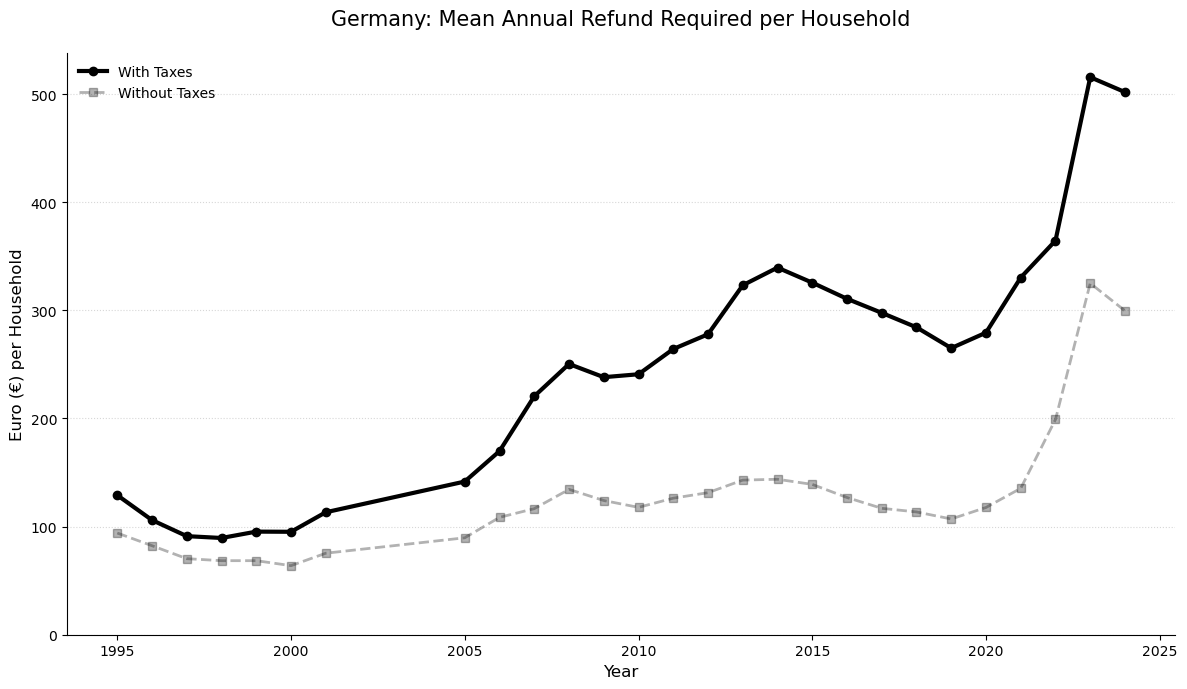

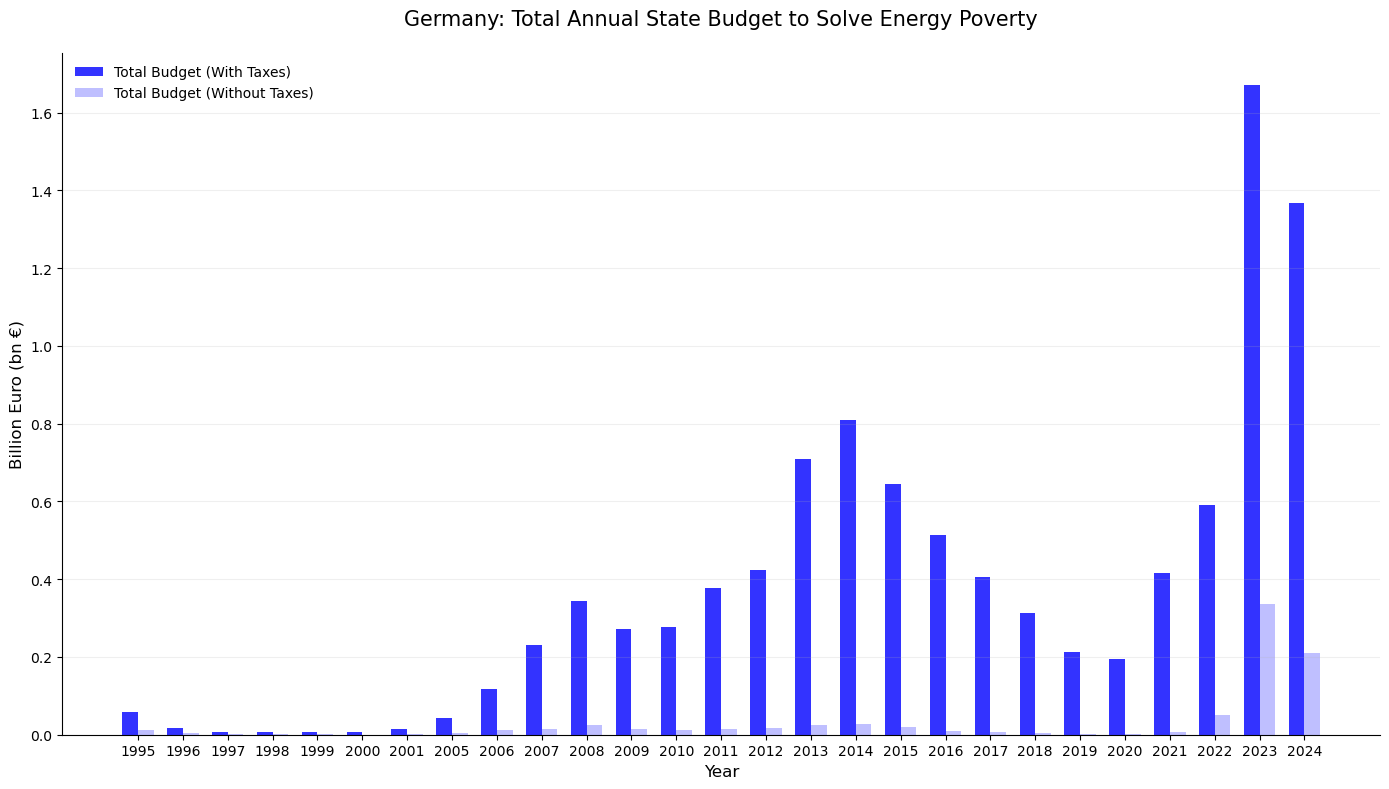

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm
from scipy.integrate import quad

# --- 1. Constants ---
# Using your 85M / 3 approximation (~28.33 Million Households)
TOTAL_GER_HOUSEHOLDS = 85_000_000 / 3 

def get_mean_gap(row, tax_type='WithTaxes'):
    """ Calculates the exact mean gap using the integral of (Cost - 10% Income) """
    mu = row['mu']
    sigma = row['sigma']
    cost = row[f'Total_Energy_Cost_{tax_type}']
    threshold = cost * 10
    
    # The Gap Function: (Cost - 10% of Income) * PDF(Income)
    def gap_func(x):
        return (cost - 0.10 * x) * lognorm.pdf(x, sigma, scale=np.exp(mu))
    
    # Integrate from 0 to the critical threshold
    total_gap_integral, _ = quad(gap_func, 0, threshold)
    
    # Divide by the share of people in poverty to get the MEAN refund per affected HH
    poverty_share = lognorm.cdf(threshold, sigma, scale=np.exp(mu))
    
    return total_gap_integral / poverty_share if poverty_share > 0 else 0

# --- 2. Processing Data ---
# Merge costs and income params
df_final = pd.merge(df_costs_GER, df_params_GER_hh, on='Year')

# Calculate Mean Refund per Year
df_final['Mean_Refund_WithTax'] = df_final.apply(lambda r: get_mean_gap(r, 'WithTaxes'), axis=1)
df_final['Mean_Refund_NoTax'] = df_final.apply(lambda r: get_mean_gap(r, 'WithoutTaxes'), axis=1)

# Calculate Total State Cost in Billions
# Total Cost = Mean Refund * (Poverty Percentage / 100) * Total Households
def calc_total_bill(row, tax_type='WithTax'):
    # Determine which cost and threshold to use for the share
    cost_col = 'Total_Energy_Cost_WithTaxes' if tax_type == 'WithTax' else 'Total_Energy_Cost_WithoutTaxes'
    threshold = row[cost_col] * 10
    share = lognorm.cdf(threshold, row['sigma'], scale=np.exp(row['mu']))
    
    return (row[f'Mean_Refund_{tax_type}'] * share * TOTAL_GER_HOUSEHOLDS) / 1e9

df_final['Total_State_Bill_WithTax'] = df_final.apply(lambda r: calc_total_bill(r, 'WithTax'), axis=1)
df_final['Total_State_Bill_NoTax'] = df_final.apply(lambda r: calc_total_bill(r, 'NoTax'), axis=1)

# --- 3. Plotting ---

# --- FIGURE 1: Mean Refund per Household (Line Plot) ---
plt.figure(figsize=(12, 7))
ax1 = plt.gca()

# Germany Color Scheme (Black)
ax1.plot(df_final['Year'], df_final['Mean_Refund_WithTax'], 
         marker='o', color='black', lw=3, label='With Taxes')
ax1.plot(df_final['Year'], df_final['Mean_Refund_NoTax'], 
         marker='s', color='black', lw=2, ls='--', alpha=0.3, label='Without Taxes')

ax1.set_title("Germany: Mean Annual Refund Required per Household", fontsize=15, pad=20)
ax1.set_ylabel("Euro (€) per Household", fontsize=12)
ax1.set_xlabel("Year", fontsize=12)

# Styling
ax1.set_ylim(bottom=0)
ax1.grid(axis='y', linestyle=':', alpha=0.5) # Light trace lines for readability
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.legend(frameon=False, loc='upper left')

plt.tight_layout()
plt.show()

# --- FIGURE 2: Total State Cost (Bar Plot) ---
plt.figure(figsize=(14, 8))
ax2 = plt.gca()

x_indices = np.arange(len(df_final['Year']))
bar_width = 0.35

# State Budget Color Scheme (Blue)
# No text labels on bars as requested - rely on Y-axis
ax2.bar(x_indices - bar_width/2, df_final['Total_State_Bill_WithTax'], 
        width=bar_width, color='blue', alpha=0.8, label='Total Budget (With Taxes)')

ax2.bar(x_indices + bar_width/2, df_final['Total_State_Bill_NoTax'], 
        width=bar_width, color='blue', alpha=0.25, label='Total Budget (Without Taxes)')

# Axis Formatting
ax2.set_title("Germany: Total Annual State Budget to Solve Energy Poverty", fontsize=15, pad=20)
ax2.set_ylabel("Billion Euro (bn €)", fontsize=12)
ax2.set_xticks(x_indices)
ax2.set_xticklabels(df_final['Year'])
ax2.set_xlabel("Year", fontsize=12)

# Clean Origin and Grid
ax2.set_ylim(bottom=0)
ax2.grid(axis='y', linestyle='-', alpha=0.2) # Horizontal lines to help reading values
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend(frameon=False, loc='upper left')

# Optimization for "Hoverability" in interactive backends
# In Jupyter/Spyder, this allows the coordinates to show in the bottom right 
# when you move your mouse over the bars.
plt.tight_layout()
plt.show()